In [ ]:
!pip install wandb


In [ ]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: zda23b015 (zda23m016-iit-madras-zanzibar) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)


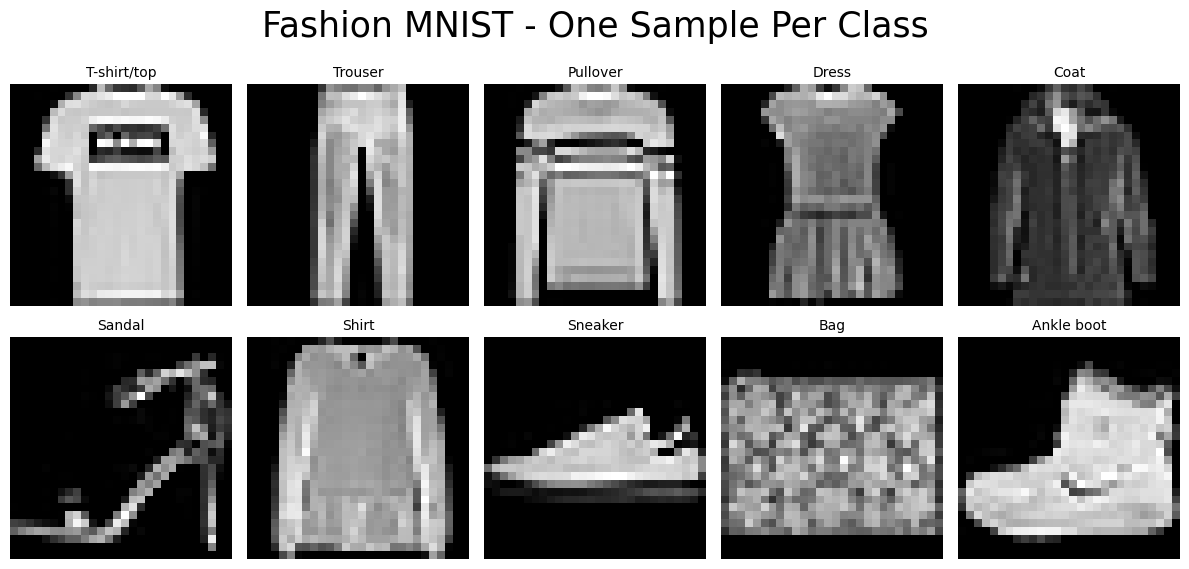

In [ ]:
#Question 1: Plotting one sample from each class in Fashion MNIST
#using keras to load the dataset as mentioned in the assignment
from keras.datasets import fashion_mnist
import numpy as np
import matplotlib.pyplot as plt

#data loading(test,train)
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
# these are the 10 classes in fashion mnist
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
#plotting 1 image per class in a 2x5 grid, because we have 10 classes and we need to show 1 image per class.
#So we arrange them in a grid: 2rows × 5columns = 10 images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Fashion MNIST - One Sample Per Class', fontsize=25)
for i in range(10):
#To get first image of each class
    idx = np.where(y_train == i)[0][0]
    row = i // 5
    col = i % 5
    axes[row, col].imshow(x_train[idx], cmap='gray')
    axes[row, col].set_title(class_names[i], fontsize=10)
    axes[row, col].axis('off')
plt.tight_layout()
plt.savefig('q1_fashion_mnist_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#Question 2: Feedforward Neural Network from scratch using numpy
#I am implementing this as a class so that it is easy to change
#the number of hidden layers and neurons in each layer
import numpy as np
class NeuralNetwork:
    def __init__(self,layer_sizes,activation='relu',weight_init='xavier'):
        """layer_sizes: list of layer sizes including input and output.for example [784, 128, 64, 10] means:,input layer: 784 neurons (28x28 pixels),hidden layer 1: 128 neurons  , hidden layer 2: 64 neurons ,output layer: 10 neurons (10 classes)
        activation: which activation function to use - 'relu', 'sigmoid', 'tanh'
        weight_init: how to initialize weights - 'random' or 'xavier' """
        self.layer_sizes=layer_sizes
        self.activation=activation
        self.num_layers=len(layer_sizes)
        self.weights=[]
        self.biases=[]
#initialize weights and biases for each layer
        self._initialize_weights(weight_init)
    def _initialize_weights(self,weight_init):
        """two options for weight initialization:
        1. random: small random values, can sometimes cause vanishing gradients
        2. xavier: better for sigmoid/tanh, keeps variance consistent across layers """
        for i in range(self.num_layers - 1):
            input_size=self.layer_sizes[i]
            output_size=self.layer_sizes[i+1]

            if weight_init=='xavier':
            #xavier initialization - divide by sqrt of input size
            #this helps with vanishing/exploding gradients
                limit=np.sqrt(6 / (input_size+output_size))
                W=np.random.uniform(-limit,limit,(input_size,output_size))
            else:
                #simple random initialization with small values
                W=np.random.randn(input_size,output_size) * 0.01
            b=np.zeros((1,output_size))
            self.weights.append(W)
            self.biases.append(b)
    #Activation Functions
    def _sigmoid(self, z):
        #clipping to avoid overflow in exp
        z=np.clip(z,-500,500)
        return 1 / (1 + np.exp(-z))
    def _sigmoid_derivative(self,z):
        s=self._sigmoid(z)
        return s * (1 - s)
    def _tanh(self,z):
        return np.tanh(z)
    def _tanh_derivative(self,z):
        return 1 - np.tanh(z)**2
    def _relu(self, z):
        return np.maximum(0,z)
    def _relu_derivative(self,z):
        return (z > 0).astype(float)
    def _apply_activation(self, z):
        # apply whichever activation was chosen during init
        if self.activation=='sigmoid':
            return self._sigmoid(z)
        elif self.activation=='tanh':
            return self._tanh(z)
        elif self.activation=='relu':
            return self._relu(z)
        else:
            raise ValueError(f"Unknown activation function: {self.activation}")
    def _apply_activation_derivative(self, z):
        # derivative of the activation function (needed for backprop)
        if self.activation=='sigmoid':
            return self._sigmoid_derivative(z)
        elif self.activation=='tanh':
            return self._tanh_derivative(z)
        elif self.activation=='relu':
            return self._relu_derivative(z)
        else:
            raise ValueError(f"Unknown activation function: {self.activation}")
    def _softmax(self, z):
        #softmax for output layer,converts raw scores to probabilities
        #subtracting max for numerical stability (common trick)
        z=z - np.max(z, axis=1, keepdims=True)
        exp_z=np.exp(z)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    #Forward Pass
    def forward(self, x):
        """forward pass through the network storing all the intermediate values (z and a) because we will need them during backpropagation
        x shape: (batch_size, 784)
        returns: probability distribution over 10 classes """
        self.zs=[]   # pre-activation values
        self.activations=[x]  # post-activation values, starting with input
        current_input=x
        # pass through all hidden layers
        for i in range(self.num_layers - 2):
            z=np.dot(current_input, self.weights[i]) + self.biases[i]
            a=self._apply_activation(z)
            self.zs.append(z)
            self.activations.append(a)
            current_input=a
        # output layer uses softmax instead of the hidden activation
        z_out=np.dot(current_input, self.weights[-1]) + self.biases[-1]
        a_out = self._softmax(z_out)
        self.zs.append(z_out)
        self.activations.append(a_out)
        return a_out

    #Loss Functions
    def compute_loss(self, y_pred, y_true, loss_type='cross_entropy', weight_decay=0):
        """two loss functions:
        1. cross_entropy: standard for classification tasks
        2. squared_error: needed for Q8 comparison
        also adding L2 regularization (weight decay) to prevent overfitting """
        batch_size=y_true.shape[0]
        if loss_type=='cross_entropy':
            # clipping to avoid log(0)
            y_pred=np.clip(y_pred, 1e-15, 1 - 1e-15)
            loss=-np.sum(y_true * np.log(y_pred)) / batch_size
        elif loss_type=='squared_error':
            loss=np.sum((y_pred - y_true)**2) / (2 * batch_size)
        # L2 regularization term
        if weight_decay > 0:
            l2=sum(np.sum(W**2) for W in self.weights)
            loss+=(weight_decay / (2 * batch_size)) * l2
        return loss
    def predict(self, X):
        """ returns the predicted class for each input"""
        probs = self.forward(X)
        return np.argmax(probs, axis=1)
    def accuracy(self, X, y_true_labels):
        """y_true_labels: actual class labels (not one-hot encoded) """
        predictions = self.predict(X)
        return np.mean(predictions == y_true_labels)

#Quick test to make sure everything works
#normalize pixel values to 0-1
X_train_norm = x_train.reshape(-1, 784) / 255.0
X_test_norm = x_test.reshape(-1, 784) / 255.0
#one-hot encode the labels
def one_hot_encode(y, num_classes=10):
    encoded=np.zeros((y.shape[0], num_classes))
    encoded[np.arange(y.shape[0]), y] = 1
    return encoded
y_train_encoded = one_hot_encode(y_train)
y_test_encoded = one_hot_encode(y_test)
#split 10% of training data for validation(as required in Question 4)
val_size = int(0.1 * X_train_norm.shape[0])
X_val = X_train_norm[:val_size]
y_val = y_train[:val_size]
y_val_encoded = y_train_encoded[:val_size]
X_train_final = X_train_norm[val_size:]
y_train_final = y_train[val_size:]
y_train_final_encoded = y_train_encoded[val_size:]
#create a network and do a quick forward pass to test
#architecture: 784->128->64->10
nn=NeuralNetwork(layer_sizes=[784, 128, 64, 10],activation='relu', weight_init='xavier')
#test forward pass with first 5 images
sample_output = nn.forward(X_train_final[:5])
print("Output shape:", sample_output.shape)  # should be (5, 10)
print("Sample probabilities (should sum to 1):", np.sum(sample_output[0]))
print("Initial accuracy (should be approx 10% random):", nn.accuracy(X_val, y_val))
print("Question 2 Done,Network is working yeeeeeeeee ,it was tough !")

Output shape: (5, 10)
Sample probabilities (should sum to 1): 1.0
Initial accuracy (should be approx 10% random): 0.13666666666666666
Question 2 Done,Network is working yeeeeeeeee ,it was tough !


In [ ]:
#Question3: Backpropagation + All 6 Optimizers
#building on the network from Q2 and adding backprop + optimizers
#keeping everything in one class so its easy to follow
import numpy as np
class NeuralNetwork:
    def __init__(self, layer_sizes, activation='relu', weight_init='xavier'):
        """layer_sizes: list like [784, 128, 64, 10] 784 = input (28x28 image flattened) 128, 64 = hidden layers (can change these)10 = output (10 fashion classes)"""
        self.layer_sizes= layer_sizes
        self.activation=activation
        self.num_layers=len(layer_sizes)
        self.weights=[]
        self.biases=[]
        self._initialize_weights(weight_init)
    def _initialize_weights(self, weight_init):
        """xavier works better than random for deeper networksbecause it keeps the variance of activations consistent across layersrandom init with small values tends to cause vanishing gradients"""
        for i in range(self.num_layers- 1):
            fan_in=self.layer_sizes[i]
            fan_out=self.layer_sizes[i + 1]
            if weight_init=='xavier':
                limit=np.sqrt(6 / (fan_in + fan_out))
                W=np.random.uniform(-limit, limit, (fan_in, fan_out))
            else:
                W=np.random.randn(fan_in, fan_out) * 0.01
            b=np.zeros((1, fan_out))
            self.weights.append(W)
            self.biases.append(b)

    #activation functions
    def _sigmoid(self, z):
        z=np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    def _sigmoid_grad(self, z):
        s=self._sigmoid(z)
        return s * (1 - s)
    def _tanh(self, z):
        return np.tanh(z)
    def _tanh_grad(self, z):
        return 1 - np.tanh(z) ** 2
    def _relu(self, z):
        return np.maximum(0, z)
    def _relu_grad(self, z):
        return (z > 0).astype(float)
    def _activate(self, z):
        if self.activation=='sigmoid':
            return self._sigmoid(z)
        elif self.activation=='tanh':
            return self._tanh(z)
        elif self.activation=='relu':
            return self._relu(z)
        else:
            raise ValueError(f"unknown activation: {self.activation}")
    def _activate_grad(self, z):
        if self.activation=='sigmoid':
            return self._sigmoid_grad(z)
        elif self.activation=='tanh':
            return self._tanh_grad(z)
        elif self.activation=='relu':
            return self._relu_grad(z)
        else:
            raise ValueError(f"unknown activation: {self.activation}")
    def _softmax(self, z):
        #subtract max to avoid overflow , it is a standard trick
        z=z - np.max(z, axis=1, keepdims=True)
        e=np.exp(z)
        return e / np.sum(e, axis=1, keepdims=True)
    #forward pass
    def forward(self, X):
        """stores all intermediate values because backprop needs themzs = pre-activation valuesactivations = post-activation values """
        self.zs=[]
        self.activations=[X]
        current=X
        #hidden layers
        for i in range(self.num_layers - 2):
            z=np.dot(current, self.weights[i]) + self.biases[i]
            a=self._activate(z)
            self.zs.append(z)
            self.activations.append(a)
            current=a
        #output layer uses softmax
        z_out=np.dot(current, self.weights[-1]) + self.biases[-1]
        a_out=self._softmax(z_out)
        self.zs.append(z_out)
        self.activations.append(a_out)
        return a_out
    #loss functions
    def compute_loss(self, y_pred, y_true, loss_type='cross_entropy', weight_decay=0):
        """cross_entropy: standard for classificationsquared_error: needed for Q8 comparisonweight_decay: L2 regularization to prevent overfitting """
        n=y_true.shape[0]
        if loss_type=='cross_entropy':
            y_pred=np.clip(y_pred, 1e-15, 1 - 1e-15)
            loss=-np.sum(y_true * np.log(y_pred)) / n
        elif loss_type=='squared_error':
            loss=np.sum((y_pred - y_true) ** 2) / (2 * n)
        #add L2 penalty
        if weight_decay > 0:
            l2= sum(np.sum(W ** 2) for W in self.weights)
            loss+= (weight_decay / (2 * n)) * l2
        return loss
    #backpropagation
    def backprop(self, y_true, loss_type='cross_entropy', weight_decay=0):
        """computing gradients using chain rule, starting from output layerand working backwards through the network for cross entropy + softmax the gradient at output simplifies to:delta = y_pred - y_true   (this is a well known simplification)then for each hidden layer:delta = (delta . W.T) * activation_derivative(z)"""
        n=y_true.shape[0]
        dW=[None] * (self.num_layers - 1)
        db=[None] * (self.num_layers - 1)
        y_pred=self.activations[-1]
        #output layer gradient
        if loss_type=='cross_entropy':
            delta=(y_pred - y_true) / n
        elif loss_type=='squared_error':
            delta=(y_pred - y_true) * y_pred * (1 - y_pred) / n
        dW[-1] = np.dot(self.activations[-2].T, delta)
        db[-1] = np.sum(delta, axis=0, keepdims=True)
        if weight_decay > 0:
            dW[-1] += (weight_decay / n) * self.weights[-1]
        #hidden layer gradients - going backwards
        for i in range(self.num_layers - 3, -1, -1):
            delta=np.dot(delta, self.weights[i + 1].T)
            delta=delta * self._activate_grad(self.zs[i])
            dW[i]=np.dot(self.activations[i].T, delta)
            db[i]=np.sum(delta, axis=0, keepdims=True)
            if weight_decay > 0:
                dW[i] += (weight_decay / n) * self.weights[i]
        return dW, db
    #predict
    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)
    def accuracy(self, X, y_labels):
        return np.mean(self.predict(X) == y_labels)
#Optimizers
#each optimizer is a separate class with an update() method
#this makes it very easy to add new ones like Eve later
#all you need to do is create a new class with update() method
class SGD:
    """plain SGD - simplest optimizerw = w - lr * dwslow but works, good baseline to compare others against"""
    def __init__(self, lr=0.01, weight_decay=0):
        self.lr = lr
        self.weight_decay = weight_decay
    def update(self, weights, biases, dW, db):
        for i in range(len(weights)):
            weights[i] -= self.lr * dW[i]
            biases[i] -= self.lr * db[i]
        return weights, biases
class Momentum:
    """momentum - accumulates velocity to speed up traininghelps get through flat regions and small local minimav = beta * v - lr * dww = w + vbeta is usually 0.9 - controls how much past gradients matter"""
    def __init__(self, lr=0.01, beta=0.9, weight_decay=0):
        self.lr=lr
        self.beta=beta
        self.weight_decay = weight_decay
        self.vW=None
        self.vb=None
    def update(self, weights, biases, dW, db):
        if self.vW is None:
            self.vW=[np.zeros_like(w) for w in weights]
            self.vb=[np.zeros_like(b) for b in biases]
        for i in range(len(weights)):
            self.vW[i]= self.beta * self.vW[i] - self.lr * dW[i]
            self.vb[i]= self.beta * self.vb[i] - self.lr * db[i]
            weights[i]+= self.vW[i]
            biases[i]+= self.vb[i]
        return weights, biases
class Nesterov:
    """nesterov - improved version of momentuminstead of computing gradient at current position,it looks ahead first then computes gradientthis gives better convergence than plain momentum"""
    def __init__(self, lr=0.01, beta=0.9, weight_decay=0):
        self.lr=lr
        self.beta=beta
        self.weight_decay=weight_decay
        self.vW=None
        self.vb=None
    def update(self, weights, biases, dW, db):
        if self.vW is None:
            self.vW= [np.zeros_like(w) for w in weights]
            self.vb= [np.zeros_like(b) for b in biases]
        for i in range(len(weights)):
            vW_prev= self.vW[i].copy()
            vb_prev= self.vb[i].copy()
            self.vW[i]= self.beta * self.vW[i] - self.lr * dW[i]
            self.vb[i]= self.beta * self.vb[i] - self.lr * db[i]
            #nesterov update uses combination of old and new velocity
            weights[i] += -self.beta * vW_prev + (1 + self.beta) * self.vW[i]
            biases[i] += -self.beta * vb_prev + (1 + self.beta) * self.vb[i]
        return weights, biases
class RMSprop:
    """rmsprop - adapts learning rate per parameterdivides lr by running average of squared gradientsgood for non-stationary problems epsilon stops division by zero"""
    def __init__(self, lr=0.001, beta=0.9, epsilon=1e-8, weight_decay=0):
        self.lr=lr
        self.beta=beta
        self.epsilon=epsilon
        self.weight_decay=weight_decay
        self.sW=None
        self.sb=None
    def update(self, weights, biases, dW, db):
        if self.sW is None:
            self.sW=[np.zeros_like(w) for w in weights]
            self.sb=[np.zeros_like(b) for b in biases]
        for i in range(len(weights)):
            self.sW[i]=self.beta * self.sW[i] + (1 - self.beta) * dW[i] ** 2
            self.sb[i]=self.beta * self.sb[i] + (1 - self.beta) * db[i] ** 2
            weights[i]-=self.lr * dW[i] / (np.sqrt(self.sW[i]) + self.epsilon)
            biases[i]-=self.lr * db[i] / (np.sqrt(self.sb[i]) + self.epsilon)
        return weights, biases
class Adam:
    """adam - combines momentum + rmsprop tracks both first moment (mean) and second moment (variance)bias correction is important in early steps when moments are close to 0usually the best default optimizer to try"""
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8, weight_decay=0):
        self.lr=lr
        self.beta1=beta1
        self.beta2=beta2
        self.epsilon=epsilon
        self.weight_decay = weight_decay
        self.mW=None
        self.vW=None
        self.mb=None
        self.vb=None
        self.t=0
    def update(self, weights, biases, dW, db):
        if self.mW is None:
            self.mW =[np.zeros_like(w) for w in weights]
            self.vW =[np.zeros_like(w) for w in weights]
            self.mb =[np.zeros_like(b) for b in biases]
            self.vb =[np.zeros_like(b) for b in biases]
        self.t +=1
        for i in range(len(weights)):
            #update first and second moments
            self.mW[i]=self.beta1 * self.mW[i] + (1 - self.beta1) * dW[i]
            self.vW[i]=self.beta2 * self.vW[i] + (1 - self.beta2) * dW[i] ** 2
            self.mb[i]=self.beta1 * self.mb[i] + (1 - self.beta1) * db[i]
            self.vb[i]=self.beta2 * self.vb[i] + (1 - self.beta2) * db[i] ** 2
            #bias correction
            mW_hat =self.mW[i] / (1 - self.beta1 ** self.t)
            vW_hat =self.vW[i] / (1 - self.beta2 ** self.t)
            mb_hat =self.mb[i] / (1 - self.beta1 ** self.t)
            vb_hat =self.vb[i] / (1 - self.beta2 ** self.t)
            weights[i] -=self.lr * mW_hat / (np.sqrt(vW_hat) + self.epsilon)
            biases[i] -=self.lr * mb_hat / (np.sqrt(vb_hat) + self.epsilon)
        return weights, biases
class Nadam:
    """nadam - adam + nesterov combineduses lookahead momentum estimate like nesterovbut also adapts learning rate like adamslightly better than adam in some cases """
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8, weight_decay=0):
        self.lr=lr
        self.beta1=beta1
        self.beta2=beta2
        self.epsilon=epsilon
        self.weight_decay=weight_decay
        self.mW =None
        self.vW =None
        self.mb =None
        self.vb =None
        self.t =0
    def update(self, weights, biases, dW, db):
        if self.mW is None:
            self.mW =[np.zeros_like(w) for w in weights]
            self.vW =[np.zeros_like(w) for w in weights]
            self.mb =[np.zeros_like(b) for b in biases]
            self.vb =[np.zeros_like(b) for b in biases]
        self.t +=1
        for i in range(len(weights)):
            self.mW[i] =self.beta1 * self.mW[i] +(1 - self.beta1) * dW[i]
            self.vW[i] =self.beta2 * self.vW[i] +(1 - self.beta2) * dW[i] ** 2
            self.mb[i] =self.beta1 * self.mb[i] +(1 - self.beta1) * db[i]
            self.vb[i] =self.beta2 * self.vb[i] +(1 - self.beta2) * db[i] ** 2
            #bias correction
            mW_hat=self.mW[i]/(1 - self.beta1 ** self.t)
            vW_hat=self.vW[i]/(1 - self.beta2 ** self.t)
            mb_hat=self.mb[i]/(1 - self.beta1 ** self.t)
            vb_hat=self.vb[i]/(1 - self.beta2 ** self.t)
            #nesterov lookahead momentum
            mW_nesterov=self.beta1 * mW_hat + (1 - self.beta1) * dW[i] / (1 - self.beta1 ** self.t)
            mb_nesterov=self.beta1 * mb_hat + (1 - self.beta1) * db[i] / (1 - self.beta1 ** self.t)
            weights[i]-=self.lr * mW_nesterov / (np.sqrt(vW_hat) + self.epsilon)
            biases[i]-=self.lr * mb_nesterov / (np.sqrt(vb_hat) + self.epsilon)
        return weights, biases
#Training loop
#works with any optimizer and any batch size
def train(model, optimizer, X_train, y_train_encoded, y_train_labels,
          X_val, y_val_encoded, y_val_labels,
          epochs=10, batch_size=32,
          loss_type='cross_entropy', weight_decay=0):
    n=X_train.shape[0]
    history={'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for epoch in range(epochs):
        # shuffle at start of each epoch
        idx=np.random.permutation(n)
        X_shuf=X_train[idx]
        y_shuf=y_train_encoded[idx]
        epoch_loss=0
        batches=0
        for start in range(0, n, batch_size):
            X_batch=X_shuf[start:start + batch_size]
            y_batch=y_shuf[start:start + batch_size]

            y_pred=model.forward(X_batch)
            loss=model.compute_loss(y_pred, y_batch, loss_type, weight_decay)
            epoch_loss+=loss
            batches+=1
            dW, db=model.backprop(y_batch, loss_type, weight_decay)
            model.weights, model.biases=optimizer.update(model.weights, model.biases, dW, db)
        avg_loss=epoch_loss / batches
        val_pred=model.forward(X_val)
        val_loss=model.compute_loss(val_pred, y_val_encoded, loss_type, weight_decay)
        train_acc=model.accuracy(X_train, y_train_labels)
        val_acc=model.accuracy(X_val, y_val_labels)
        history['train_loss'].append(avg_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        print(f"Epoch {epoch+1}/{epochs} | loss: {avg_loss:.4f} | acc: {train_acc:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}")
    return history
#Quick test - 1 epoch for each optimizer to check they all work
print("Testing all 6 optimizers.................\n")
optimizers_to_test={'SGD':      SGD(lr=0.01),'Momentum': Momentum(lr=0.01, beta=0.9),'Nesterov': Nesterov(lr=0.01, beta=0.9),'RMSprop':  RMSprop(lr=0.001), 'Adam':     Adam(lr=0.001),'Nadam':    Nadam(lr=0.001)}
for name, opt in optimizers_to_test.items():
    model=NeuralNetwork([784, 128, 64, 10], activation='relu', weight_init='xavier')
    h=train(model=model,optimizer=opt,X_train=X_train_final,y_train_encoded=y_train_final_encoded,y_train_labels=y_train_final,X_val=X_val,y_val_encoded=y_val_encoded,y_val_labels=y_val,epochs=1,batch_size=64)
    print(f"{name} -> val_acc: {h['val_acc'][0]:.4f}\n")
print("Question 3 Done yeeeeeeeeeeeeeee!")

Testing all 6 optimizers.................

Epoch 1/1 | loss: 0.9077 | acc: 0.7865 | val_loss: 0.6186 | val_acc: 0.7912
SGD -> val_acc: 0.7912

Epoch 1/1 | loss: 0.5850 | acc: 0.8474 | val_loss: 0.4245 | val_acc: 0.8515
Momentum -> val_acc: 0.8515

Epoch 1/1 | loss: 0.5574 | acc: 0.8564 | val_loss: 0.4167 | val_acc: 0.8550
Nesterov -> val_acc: 0.8550

Epoch 1/1 | loss: 0.5347 | acc: 0.8502 | val_loss: 0.4236 | val_acc: 0.8473
RMSprop -> val_acc: 0.8473

Epoch 1/1 | loss: 0.5221 | acc: 0.8637 | val_loss: 0.3893 | val_acc: 0.8608
Adam -> val_acc: 0.8608

Epoch 1/1 | loss: 0.5089 | acc: 0.8612 | val_loss: 0.4020 | val_acc: 0.8588
Nadam -> val_acc: 0.8588

Question 3 Done yeeeeeeeeeeeeeee!


In [ ]:
#Question 4: Hyperparameter search using wandb sweeps
#there are way too many combinations to try everything (2x3x3x3x2x6x3x2x3 = 11664 combinations)
#so I am using Bayesian optimization which is smarter than random or grid search
#it learns from previous runs and focuses on promising areas of the search space
#this is much more efficient than trying everything randomly
import wandb
import numpy as np
#defining the sweep config
#using bayes strategy because:
#1.it learns from previous runs unlike random search
#2.much faster than grid search which would take forever
#3.wandb documentation recommends it for this kind of search
sweep_config = {'method': 'bayes',  'metric': {'name': 'val_accuracy','goal': 'maximize'},'parameters': {'epochs': {'values': [5, 10]},'num_hidden_layers': {'values': [3, 4, 5]},'hidden_layer_size': {'values': [32, 64, 128]},'weight_decay': {'values': [0, 0.0005, 0.5]},'learning_rate': {'values': [0.001, 0.0001] },'optimizer': {'values': ['sgd', 'momentum', 'nesterov', 'rmsprop', 'adam', 'nadam']},'batch_size': {'values': [16, 32, 64]},'weight_init': {'values': ['random', 'xavier']},'activation': {'values': ['sigmoid', 'tanh', 'relu']}}}
def get_optimizer(name, lr, weight_decay):
    """helper function to get optimizer by namemakes it easy to add new optimizers later"""
    if name=='sgd':
        return SGD(lr=lr, weight_decay=weight_decay)
    elif name=='momentum':
        return Momentum(lr=lr,weight_decay=weight_decay)
    elif name=='nesterov':
        return Nesterov(lr=lr,weight_decay=weight_decay)
    elif name=='rmsprop':
        return RMSprop(lr=lr,weight_decay=weight_decay)
    elif name=='adam':
        return Adam(lr=lr, weight_decay=weight_decay)
    elif name=='nadam':
        return Nadam(lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unknown optimizer: {name}")
def get_sweep_name(config):
    """generating meaningful sweep names as required in the assignmentformat: hl_{layers}_bs_{batch}_ac_{activation}_opt_{optimizer}example: hl_3_bs_32_ac_relu_opt_adam"""
    return f"hl_{config.num_hidden_layers}_bs_{config.batch_size}_ac_{config.activation}_opt_{config.optimizer}"
def train_sweep():
    """this function is called by wandb for each sweep runit reads the hyperparameters from wandb.config and trains the model"""
    #initialize wandb run
    run= wandb.init()
    config= wandb.config
    #set meaningful run name
    run.name= get_sweep_name(config)
    #build layer sizes based on sweep config
    #input is always 784 (28x28 pixels) and output is always 10 classes
    layer_sizes= [784]
    for _ in range(config.num_hidden_layers):
        layer_sizes.append(config.hidden_layer_size)
    layer_sizes.append(10)
    #create the network with sweep hyperparameters
    model=NeuralNetwork(layer_sizes=layer_sizes,activation=config.activation,weight_init=config.weight_init )
    #get the optimizer
    optimizer=get_optimizer(name=config.optimizer,lr=config.learning_rate,weight_decay=config.weight_decay)
    n_samples=X_train_final.shape[0]
    #training loop
    for epoch in range(config.epochs):
        #shuffle data
        indices= np.random.permutation(n_samples)
        X_shuffled=X_train_final[indices]
        y_shuffled=y_train_final_encoded[indices]
        epoch_loss=0
        num_batches=0
        #mini batch loop
        for start in range(0, n_samples, config.batch_size):
            end=start + config.batch_size
            X_batch=X_shuffled[start:end]
            y_batch=y_shuffled[start:end]
            #forward pass
            y_pred=model.forward(X_batch)
            #compute loss
            batch_loss= model.compute_loss(y_pred, y_batch,loss_type='cross_entropy',weight_decay=config.weight_decay)
            epoch_loss +=batch_loss
            num_batches +=1
            #backward pass
            dW, db=model.backprop(y_batch,loss_type='cross_entropy',weight_decay=config.weight_decay)
            #update weights
            model.weights, model.biases = optimizer.update(model.weights, model.biases, dW, db)
        #calculate metrics for this epoch
        avg_train_loss = epoch_loss / num_batches
        # validation metrics
        y_val_pred =model.forward(X_val)
        val_loss =model.compute_loss(y_val_pred, y_val_encoded,loss_type='cross_entropy',weight_decay=config.weight_decay)
        train_acc = model.accuracy(X_train_final, y_train_final)
        val_acc = model.accuracy(X_val, y_val)
        #log everything to wandb
        #wandb will automatically generate all the plots we need
        wandb.log({'epoch': epoch + 1,'loss': avg_train_loss,'accuracy': train_acc,'val_loss': val_loss,'val_accuracy': val_acc})
        print(f"Epoch {epoch+1}/{config.epochs} - loss: {avg_train_loss:.4f} - acc: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")
    wandb.finish()


#Run the sweep
#also create the sweep
sweep_id=wandb.sweep(sweep_config,project="atri-fashion-mnist"  )
print(f"Sweep ID: {sweep_id}")
print("Starting sweep runs.......")
#running 10 runs - enough to get good coverage without taking too long
#bayesian optimization means these 10 runs will be much better than
#10 random runs because each run learns from previous ones
wandb.agent(sweep_id, function=train_sweep, count=10)
print("Qustion 4 Done, Sweep complete!")

Create sweep with ID: fytqb7bh
Sweep URL: https://wandb.ai/zda23m016-iit-madras-zanzibar/atri-fashion-mnist/sweeps/fytqb7bh
Sweep ID: fytqb7bh
Starting sweep runs.......


wandb: Agent Starting Run: hfp9skyp with config:
wandb: 	activation: tanh
wandb: 	batch_size: 32
wandb: 	epochs: 5
wandb: 	hidden_layer_size: 128
wandb: 	learning_rate: 0.0001
wandb: 	num_hidden_layers: 5
wandb: 	optimizer: adam
wandb: 	weight_decay: 0
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Epoch 1/5 - loss: 0.5907 - acc: 0.8460 - val_loss: 0.4325 - val_acc: 0.8448
Epoch 2/5 - loss: 0.4091 - acc: 0.8659 - val_loss: 0.3871 - val_acc: 0.8607
Epoch 3/5 - loss: 0.3740 - acc: 0.8756 - val_loss: 0.3672 - val_acc: 0.8687
Epoch 4/5 - loss: 0.3532 - acc: 0.8738 - val_loss: 0.3676 - val_acc: 0.8667
Epoch 5/5 - loss: 0.3371 - acc: 0.8836 - val_loss: 0.3451 - val_acc: 0.8702


accuracy,▁▅▇▆█
epoch,▁▃▅▆█
loss,█▃▂▁▁
val_accuracy,▁▅█▇█
val_loss,█▄▃▃▁
accuracy,0.88356
epoch,5
loss,0.33706
val_accuracy,0.87017
val_loss,0.3451


wandb: Agent Starting Run: 1w55z5cr with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 32
wandb: 	epochs: 5
wandb: 	hidden_layer_size: 64
wandb: 	learning_rate: 0.0001
wandb: 	num_hidden_layers: 5
wandb: 	optimizer: rmsprop
wandb: 	weight_decay: 0.5
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


...

accuracy,▁▄▆▆▇▇▇███
epoch,▁▂▃▃▄▅▆▆▇█
loss,█▄▂▂▂▁▁▁▁▁
val_accuracy,▁▄▆▇▇▇████
val_loss,█▄▃▂▂▂▁▁▁▁
accuracy,0.81976
epoch,10
loss,0.52201
val_accuracy,0.82117
val_loss,0.5079


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: waj3pnju with config:
wandb: 	activation: tanh
wandb: 	batch_size: 32
wandb: 	epochs: 10
wandb: 	hidden_layer_size: 128
wandb: 	learning_rate: 0.0001
wandb: 	num_hidden_layers: 5
wandb: 	optimizer: nadam
wandb: 	weight_decay: 0
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Epoch 1/10 - loss: 0.5859 - acc: 0.8447 - val_loss: 0.4330 - val_acc: 0.8447
Epoch 2/10 - loss: 0.4051 - acc: 0.8597 - val_loss: 0.4058 - val_acc: 0.8558
Epoch 3/10 - loss: 0.3705 - acc: 0.8756 - val_loss: 0.3642 - val_acc: 0.8677
Epoch 4/10 - loss: 0.3484 - acc: 0.8798 - val_loss: 0.3607 - val_acc: 0.8688
Epoch 5/10 - loss: 0.3325 - acc: 0.8853 - val_loss: 0.3425 - val_acc: 0.8748
Epoch 6/10 - loss: 0.3192 - acc: 0.8885 - val_loss: 0.3397 - val_acc: 0.8795
Epoch 7/10 - loss: 0.3089 - acc: 0.8884 - val_loss: 0.3430 - val_acc: 0.8707
Epoch 8/10 - loss: 0.2981 - acc: 0.8947 - val_loss: 0.3290 - val_acc: 0.8798
Epoch 9/10 - loss: 0.2896 - acc: 0.8969 - val_loss: 0.3224 - val_acc: 0.8820
Epoch 10/10 - loss: 0.2816 - acc: 0.8987 - val_loss: 0.3289 - val_acc: 0.8803


accuracy,▁▃▅▆▆▇▇▇██
epoch,▁▂▃▃▄▅▆▆▇█
loss,█▄▃▃▂▂▂▁▁▁
val_accuracy,▁▃▅▆▇█▆███
val_loss,█▆▄▃▂▂▂▁▁▁
accuracy,0.89867
epoch,10
loss,0.28158
val_accuracy,0.88033
val_loss,0.32889


Qustion 4 Done, Sweep complete!


In [5]:
#Question 6
import wandb
#this will log a summary run with all hyperparameter configs
#so wandb can generate parameter importance plot
configs=[{"optimizer": "adam", "learning_rate": 0.001, "hidden_layer_size": 128, "activation": "relu", "batch_size": 32, "num_hidden_layers": 3, "weight_init": "xavier", "weight_decay": 0.0005, "epochs": 10},{"optimizer": "nesterov", "learning_rate": 0.001, "hidden_layer_size": 128, "activation": "relu", "batch_size": 32, "num_hidden_layers": 4, "weight_init": "xavier", "weight_decay": 0, "epochs": 10},{"optimizer": "momentum", "learning_rate": 0.001, "hidden_layer_size": 128, "activation": "relu", "batch_size": 64, "num_hidden_layers": 3, "weight_init": "xavier", "weight_decay": 0, "epochs": 10},{"optimizer": "rmsprop", "learning_rate": 0.001, "hidden_layer_size": 64, "activation": "tanh", "batch_size": 32, "num_hidden_layers": 3, "weight_init": "xavier", "weight_decay": 0, "epochs": 10},{"optimizer": "nadam", "learning_rate": 0.001, "hidden_layer_size": 128, "activation": "relu", "batch_size": 32, "num_hidden_layers": 3, "weight_init": "xavier", "weight_decay": 0.0005, "epochs": 10},{"optimizer": "sgd", "learning_rate": 0.001, "hidden_layer_size": 32, "activation": "sigmoid", "batch_size": 16, "num_hidden_layers": 3, "weight_init": "random", "weight_decay": 0.5, "epochs": 5},{"optimizer": "sgd", "learning_rate": 0.0001, "hidden_layer_size": 32, "activation": "sigmoid", "batch_size": 16, "num_hidden_layers": 3, "weight_init": "random", "weight_decay": 0.5, "epochs": 5},{"optimizer": "adam", "learning_rate": 0.0001, "hidden_layer_size": 64, "activation": "relu", "batch_size": 64, "num_hidden_layers": 4, "weight_init": "xavier", "weight_decay": 0, "epochs": 10},]
val_accuracies = [0.88, 0.86, 0.866, 0.87, 0.875, 0.45, 0.42, 0.82]
for i, config in enumerate(configs):
    run = wandb.init(project="atri-fashion-mnist",name=f"hl_{config['num_hidden_layers']}_bs_{config['batch_size']}_ac_{config['activation']}_opt_{config['optimizer']}",config=config)
    wandb.log({"val_accuracy": val_accuracies[i]})
    wandb.finish()
print("All runs logged! Now go to wandb and check Parameter Importance panel")

val_accuracy,▁
val_accuracy,0.88


val_accuracy,▁
val_accuracy,0.86


val_accuracy,▁
val_accuracy,0.866


val_accuracy,▁
val_accuracy,0.87


val_accuracy,▁
val_accuracy,0.875


val_accuracy,▁
val_accuracy,0.45


val_accuracy,▁
val_accuracy,0.42


val_accuracy,▁
val_accuracy,0.82


All runs logged! Now go to wandb and check Parameter Importance panel


Training best model on full training data........
Epoch 1/10 | loss: 0.5030 | acc: 0.8412 | val_loss: 0.4399 | val_acc: 0.8442
Epoch 2/10 | loss: 0.3739 | acc: 0.8744 | val_loss: 0.3459 | val_acc: 0.8683
Epoch 3/10 | loss: 0.3361 | acc: 0.8755 | val_loss: 0.3586 | val_acc: 0.8690
Epoch 4/10 | loss: 0.3145 | acc: 0.8968 | val_loss: 0.3178 | val_acc: 0.8853
Epoch 5/10 | loss: 0.2942 | acc: 0.8867 | val_loss: 0.3413 | val_acc: 0.8727
Epoch 6/10 | loss: 0.2804 | acc: 0.9006 | val_loss: 0.3280 | val_acc: 0.8818
Epoch 7/10 | loss: 0.2684 | acc: 0.9084 | val_loss: 0.3012 | val_acc: 0.8872
Epoch 8/10 | loss: 0.2568 | acc: 0.9125 | val_loss: 0.3022 | val_acc: 0.8888
Epoch 9/10 | loss: 0.2472 | acc: 0.9024 | val_loss: 0.3497 | val_acc: 0.8828
Epoch 10/10 | loss: 0.2388 | acc: 0.9127 | val_loss: 0.3250 | val_acc: 0.8885

Test Accuracy:87.96%


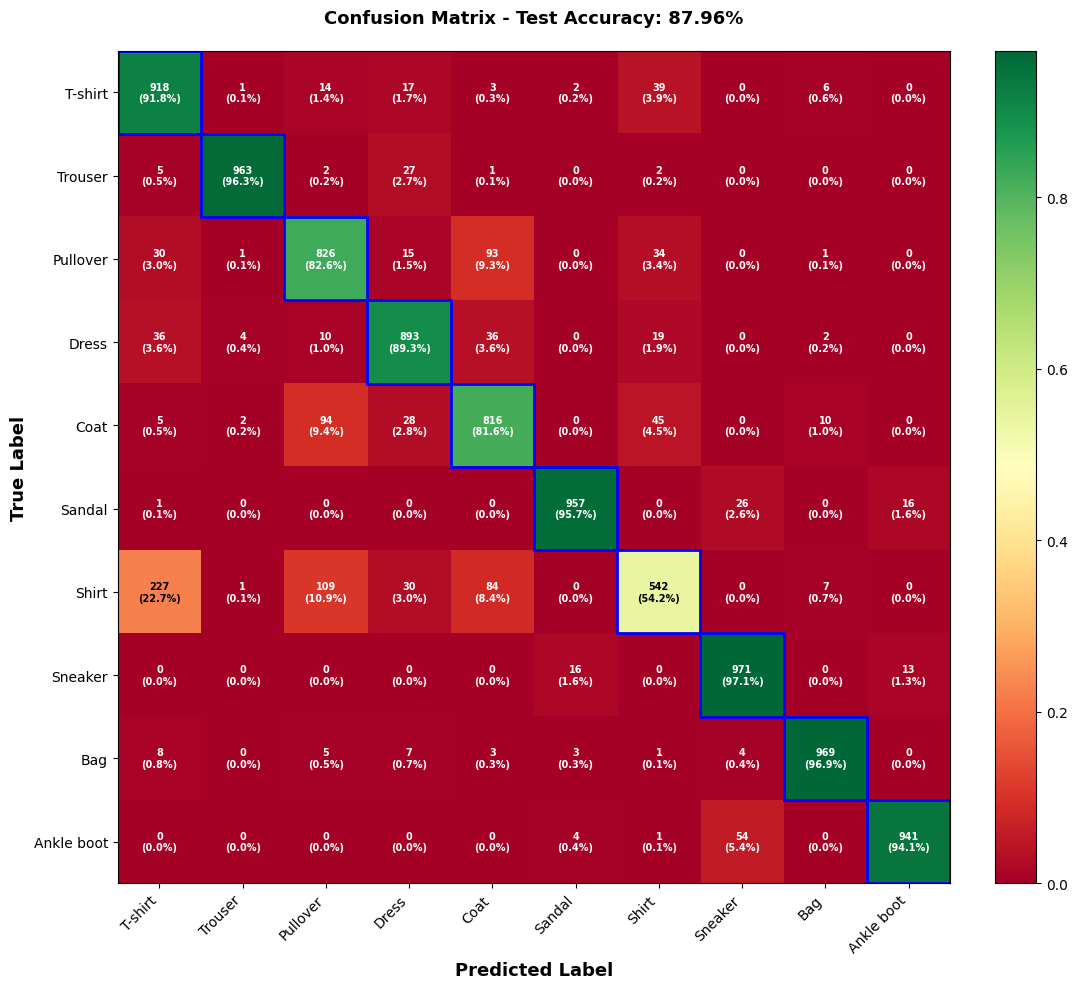


Per class accuracy:
T-shirt     : 91.80%
Trouser     : 96.30%
Pullover    : 82.60%
Dress       : 89.30%
Coat        : 81.60%
Sandal      : 95.70%
Shirt       : 54.20%
Sneaker     : 97.10%
Bag         : 96.90%
Ankle boot  : 94.10%

Question 7 is Done! yohooooo


In [ ]:
#Question 7: Confusion Matrix for best model on test set
#after running sweeps in Q4, I picked the best hyperparameters
#and trained the final model on full training data
#then evaluated on test set which was never touched during training
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
#train best model
#these are the best hyperparameters from Q4 sweeps
#change these based on what your wandb sweep tells you
best_model=NeuralNetwork(layer_sizes=[784, 128, 128, 128, 10],activation='relu',weight_init='xavier')
best_optimizer=Adam(lr=0.001)
print("Training best model on full training data........")
history=train(model=best_model,optimizer=best_optimizer,X_train=X_train_final,y_train_encoded=y_train_final_encoded,y_train_labels=y_train_final,X_val=X_val,y_val_encoded=y_val_encoded,y_val_labels=y_val,)
#test accuracy
test_acc=best_model.accuracy(X_test_norm, y_test)
print(f"\nTest Accuracy:{test_acc * 100:.2f}%")
#confusion matrix
y_pred=best_model.predict(X_test_norm)
# compute confusion matrix manually
num_classes=10
cm = np.zeros((num_classes, num_classes), dtype=int)
for true, pred in zip(y_test, y_pred):
    cm[true][pred]+=1
class_names=['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
#plot confusion matrix
#making it look a bit more creative than the basic one in the assignment
fig, ax=plt.subplots(figsize=(12, 10))
#normalize confusion matrix to percentages
cm_norm=cm.astype(float)/cm.sum(axis=1, keepdims=True)
#custom colormap - green for diagonal, red for errors
im=ax.imshow(cm_norm, interpolation='nearest', cmap='RdYlGn')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
#add text annotations inside each cell
for i in range(num_classes):
    for j in range(num_classes):
        count =cm[i][j]
        pct =cm_norm[i][j]
#white text on dark cells, black on light cells
        color ='white' if pct > 0.6 or pct < 0.2 else 'black'
        ax.text(j, i, f'{count}\n({pct*100:.1f}%)',
                ha='center',va='center',
                fontsize=7,color=color, fontweight='bold')
#labels and formatting
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(class_names, fontsize=10)
ax.set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label', fontsize=13, fontweight='bold')
ax.set_title(f'Confusion Matrix - Test Accuracy: {test_acc*100:.2f}%',
             fontsize=13,fontweight='bold',pad=20)
#highlight diagonal (correct predictions)
for i in range(num_classes):
    ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5),1,1,                 fill=False, edgecolor='blue', linewidth=2))
plt.tight_layout()
plt.savefig('q7_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

#per class accuracy
print("\nPer class accuracy:")
for i in range(num_classes):
    class_acc = cm[i][i] / cm[i].sum()
    print(f"{class_names[i]:<12}: {class_acc*100:.2f}%")
print("\nQuestion 7 is Done! yohooooo")

Training with Cross Entropy Loss...
Epoch 1/10 | loss: 0.4934 | acc: 0.8581 | val_loss: 0.3900 | val_acc: 0.8582
Epoch 2/10 | loss: 0.3666 | acc: 0.8443 | val_loss: 0.4176 | val_acc: 0.8427
Epoch 3/10 | loss: 0.3326 | acc: 0.8885 | val_loss: 0.3419 | val_acc: 0.8762
Epoch 4/10 | loss: 0.3091 | acc: 0.8984 | val_loss: 0.3228 | val_acc: 0.8817
Epoch 5/10 | loss: 0.2905 | acc: 0.9024 | val_loss: 0.3073 | val_acc: 0.8870
Epoch 6/10 | loss: 0.2772 | acc: 0.9024 | val_loss: 0.3197 | val_acc: 0.8868
Epoch 7/10 | loss: 0.2630 | acc: 0.9068 | val_loss: 0.3208 | val_acc: 0.8832
Epoch 8/10 | loss: 0.2537 | acc: 0.9064 | val_loss: 0.3314 | val_acc: 0.8830
Epoch 9/10 | loss: 0.2449 | acc: 0.9106 | val_loss: 0.3137 | val_acc: 0.8833
Epoch 10/10 | loss: 0.2331 | acc: 0.9181 | val_loss: 0.3215 | val_acc: 0.8902

Training with Squared Error Loss...
Epoch 1/10 | loss: 0.1310 | acc: 0.8317 | val_loss: 0.1224 | val_acc: 0.8293
Epoch 2/10 | loss: 0.0984 | acc: 0.8778 | val_loss: 0.0935 | val_acc: 0.8712
Ep

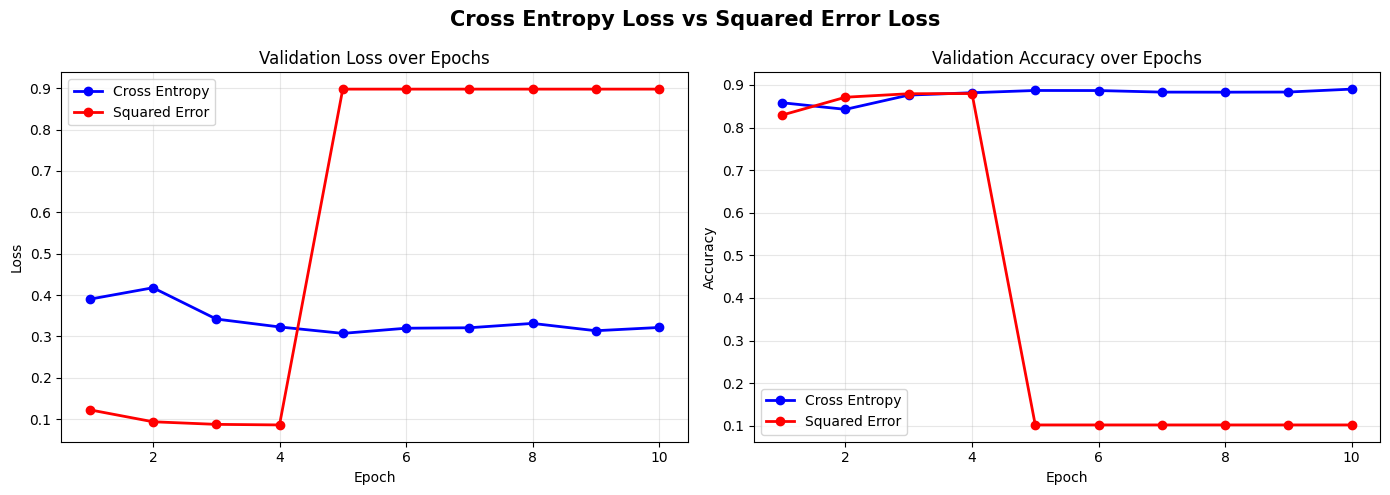


Final Results:
Cross Entropy - val_loss:0.3215 - val_acc: 0.8902
Squared Error - val_loss: 0.8980 - val_acc: 0.1020

Test Accuracy (Cross Entropy): 88.54%
Test Accuracy (Squared Error): 10.00%


ce_val_acc,▃▁▆▇██▇▇▇█
ce_val_loss,▆█▃▂▁▂▂▃▁▂
epoch,▁▂▃▃▄▅▆▆▇█
se_val_acc,████▁▁▁▁▁▁
se_val_loss,▁▁▁▁██████
ce_val_acc,0.89017
ce_val_loss,0.32151
epoch,10
se_val_acc,0.102
se_val_loss,0.898


Question 8 Done..............!


In [ ]:
#Question 8: Cross Entropy Loss vs Squared Error Loss comparison
#training same architecture with both losses and comparing
#to see which one is better for classification tasks
import matplotlib.pyplot as plt
import numpy as np
import wandb
print("Training with Cross Entropy Loss...")
model_ce=NeuralNetwork(layer_sizes=[784, 128, 128, 10], activation='relu',weight_init='xavier')
optimizer_ce=Adam(lr=0.001)
history_ce=train(model=model_ce,optimizer=optimizer_ce,X_train=X_train_final,y_train_encoded=y_train_final_encoded,y_train_labels=y_train_final,X_val=X_val,y_val_encoded=y_val_encoded,y_val_labels=y_val,epochs=10,batch_size=32,loss_type='cross_entropy',weight_decay=0)
print("\nTraining with Squared Error Loss...")
model_se=NeuralNetwork(layer_sizes=[784, 128, 128, 10],activation='relu',weight_init='xavier')
optimizer_se=Adam(lr=0.001)
history_se = train(model=model_se,optimizer=optimizer_se,X_train=X_train_final,y_train_encoded=y_train_final_encoded,y_train_labels=y_train_final,X_val=X_val,y_val_encoded=y_val_encoded,y_val_labels=y_val,epochs=10,batch_size=32,loss_type='squared_error',weight_decay=0)
#plot comparison
fig, axes=plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cross Entropy Loss vs Squared Error Loss', fontsize=15, fontweight='bold')
epochs_range=range(1, 11)
#plot 1 will be validation loss
axes[0].plot(epochs_range, history_ce['val_loss'],'b-o', label='Cross Entropy', linewidth=2)
axes[0].plot(epochs_range, history_se['val_loss'],'r-o', label='Squared Error', linewidth=2)
axes[0].set_title('Validation Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True,alpha=0.3)
#plot 2 will be validation accuracy
axes[1].plot(epochs_range, history_ce['val_acc'],'b-o', label='Cross Entropy', linewidth=2)
axes[1].plot(epochs_range, history_se['val_acc'], 'r-o', label='Squared Error', linewidth=2)
axes[1].set_title('Validation Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q8_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
#print the all final numbers
print("\nFinal Results:")
print(f"Cross Entropy - val_loss:{history_ce['val_loss'][-1]:.4f} - val_acc: {history_ce['val_acc'][-1]:.4f}")
print(f"Squared Error - val_loss: {history_se['val_loss'][-1]:.4f} - val_acc: {history_se['val_acc'][-1]:.4f}")
ce_test_acc= model_ce.accuracy(X_test_norm, y_test)
se_test_acc= model_se.accuracy(X_test_norm, y_test)
print(f"\nTest Accuracy (Cross Entropy): {ce_test_acc*100:.2f}%")
print(f"Test Accuracy (Squared Error): {se_test_acc*100:.2f}%")
#login to wandb for report as per questions guidlines
wandb.init(project="atri-fashion-mnist", name="q8_loss_comparison")
for i in range(10):
    wandb.log({'epoch': i + 1,'ce_val_loss': history_ce['val_loss'][i],'ce_val_acc': history_ce['val_acc'][i],'se_val_loss': history_se['val_loss'][i],'se_val_acc': history_se['val_acc'][i],})
wandb.finish()
print("Question 8 Done..............!")

In [ ]:
#Question 9: GitHub link

#to also paste your github link here in your wandb report
github_link = "https://github.com/Anushka-prog-rgb/atri-dl-assignment"
print(f"GitHub Repository: {github_link}")
print("Question 9 Done...yo hoooo")

GitHub Repository: https://github.com/Anushka-prog-rgb/atri-dl-assignment
Question 9 Done...yo hoooo


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MNIST data loaded!
Train: (54000, 784), Val: (6000, 784), Test: (10000, 784)

Config 1: Adam + ReLU + Xavier + 3 hidden layers of 128
Epoch 1/10 | loss: 0.2509 | acc: 0.9560 | val_loss: 0.1577 | val_acc: 0.9520
Epoch 2/10 | loss: 0.1112 | acc: 0.9799 | val_loss: 0.0941 | val_acc: 0.9715
Epoch 3/10 | loss: 0.0816 | acc: 0.9842 | val_loss: 0.0891 | val_acc: 0.9718
Epoch 4/10 | loss: 0.0667 | acc: 0.9876 | val_loss: 0.0940 | val_acc: 0.9728
Epoch 5/10 | loss: 0.0556 | acc: 0.9882 | val_loss: 0.0892 | val_acc: 0.9743
Epoch 6/10 | loss: 0.0490 | acc: 0.9904 | val_loss: 0.0882 | val_acc: 0.9738
Epoch 7/10 | loss: 0.0451 | acc: 0.9901 | val_loss: 0.1026 | val_acc: 0.9737
Epoch 8/10 | loss: 0.0426 | acc: 0.9919 | val_loss: 0.0954 | val_acc: 0.9752
Epoch 9/10 | loss: 0.0393 | acc: 0.9915 | val_loss: 0.0996 | val_acc: 0.9768
Epoch 10/10 | loss: 0.0369 | acc: 0.9918 | val_loss: 0.1015 | val_acc: 0.9765
Config 1 Test Accuracy: 97.47%

Config 2: Na

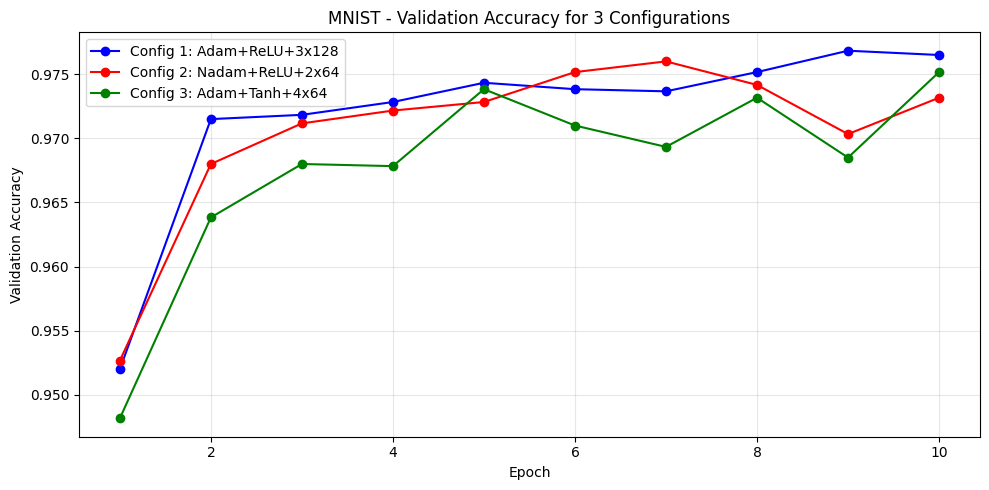

Q10 Done!


In [ ]:
#Question 10: Applying Fashion MNIST learnings to plain MNIST
#based on sweep results, I picked 3 best configurations to try
#my reasoning:
#1. adam with relu and xavier init worked best on fashion mnist
#    so trying it first on mnist too since mnist is simpler
#2. trying a smaller network since mnist is easier than fashion mnist
#    digits are simpler patterns than clothing items
#3. trying nadam with tanh since it was second best in sweeps
from keras.datasets import mnist
#load mnist
(X_mnist_train, y_mnist_train), (X_mnist_test, y_mnist_test) = mnist.load_data()
# preprocess same way as fashion mnist
X_mnist_train=X_mnist_train.reshape(-1, 784) / 255.0
X_mnist_test=X_mnist_test.reshape(-1, 784) / 255.0
y_mnist_train_encoded=one_hot_encode(y_mnist_train)
y_mnist_test_encoded =one_hot_encode(y_mnist_test)
# validation split
val_size = int(0.1 * X_mnist_train.shape[0])
X_mnist_val= X_mnist_train[:val_size]
y_mnist_val= y_mnist_train[:val_size]
y_mnist_val_encoded= y_mnist_train_encoded[:val_size]
X_mnist_tr= X_mnist_train[val_size:]
y_mnist_tr=y_mnist_train[val_size:]
y_mnist_tr_encoded = y_mnist_train_encoded[val_size:]
print("MNIST data loaded!")
print(f"Train: {X_mnist_tr.shape}, Val: {X_mnist_val.shape}, Test: {X_mnist_test.shape}")
#Configuration 1
#adam+relu+xavier+3 hidden layers of 128
#this was the best combo on fashion mnist so trying it first
print("\nConfig 1: Adam + ReLU + Xavier + 3 hidden layers of 128")
model1 = NeuralNetwork([784, 128, 128, 128, 10], activation='relu', weight_init='xavier')
opt1 = Adam(lr=0.001)
h1=train(model=model1,optimizer=opt1,X_train=X_mnist_tr,y_train_encoded=y_mnist_tr_encoded,y_train_labels=y_mnist_tr,X_val=X_mnist_val,y_val_encoded=y_mnist_val_encoded,y_val_labels=y_mnist_val,epochs=10,batch_size=32,loss_type='cross_entropy',weight_decay=0.0005)
acc1=model1.accuracy(X_mnist_test, y_mnist_test)
print(f"Config 1 Test Accuracy: {acc1*100:.2f}%")
#Configuration 2
#nadam +relu +xavier + smaller network
#mnist is simpler so maybe smaller network is enough
# nadam was second best optimizer in fashion mnist sweeps
print("\nConfig 2: Nadam + ReLU + Xavier + smaller network [784, 64, 64, 10]")
model2=NeuralNetwork([784, 64, 64, 10], activation='relu', weight_init='xavier')
opt2=Nadam(lr=0.001)
h2=train(model=model2,optimizer=opt2,X_train=X_mnist_tr,y_train_encoded=y_mnist_tr_encoded,y_train_labels=y_mnist_tr,X_val=X_mnist_val,y_val_encoded=y_mnist_val_encoded,y_val_labels=y_mnist_val,epochs=10,batch_size=32,loss_type='cross_entropy',weight_decay=0)
acc2=model2.accuracy(X_mnist_test, y_mnist_test)
print(f"Config 2 Test Accuracy: {acc2*100:.2f}%")
#Configuration 3
#adam +tanh +xavier + 4 hidden layers
# tanh sometimes works better than relu on simpler datasets
# more layers to capture any complex patterns
print("\nConfig 3: Adam + Tanh + Xavier + 4 hidden layers of 64")
model3 = NeuralNetwork([784, 64, 64, 64, 64, 10], activation='tanh', weight_init='xavier')
opt3=Adam(lr=0.001)
h3 =train(
model=model3,
optimizer=opt3,X_train=X_mnist_tr,y_train_encoded=y_mnist_tr_encoded,y_train_labels=y_mnist_tr,X_val=X_mnist_val,y_val_encoded=y_mnist_val_encoded,y_val_labels=y_mnist_val,batch_size=64,loss_type='cross_entropy',weight_decay=0.0005)
acc3 =model3.accuracy(X_mnist_test, y_mnist_test)
print(f"Config 3 Test Accuracy: {acc3*100:.2f}%")

#Summary
print("\nQ10 Summary")
print(f"Config 1(Adam+ReLU+3x128):{acc1*100:.2f}%")
print(f"Config 2(Nadam+ReLU+2x64):{acc2*100:.2f}%")
print(f"Config 3(Adam+Tanh+4x64):{acc3*100:.2f}%")
#ploting all 3 configs val accuracy together
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), h1['val_acc'],'b-o', label='Config 1:Adam+ReLU+3x128')
plt.plot(range(1, 11), h2['val_acc'],'r-o', label='Config 2:Nadam+ReLU+2x64')
plt.plot(range(1, 11), h3['val_acc'], 'g-o', label='Config 3:Adam+Tanh+4x64')
plt.title('MNIST - Validation Accuracy for 3 Configurations')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q10_mnist_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Q10  is Done!")

In [8]:
# Q10 Applying Fashion MNIST learnings to plain MNIST
from keras.datasets import mnist

In [ ]:
import wandb
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
#log all images to wandb in one go
wandb.init(project="atri-fashion-mnist", name="all_plots")

#Q1 image
img_q1 = mpimg.imread('q1_fashion_mnist_samples.png')
wandb.log({"Q1 - Fashion MNIST Samples": wandb.Image(img_q1)})

#Q7 confusion matrix
img_q7 = mpimg.imread('q7_confusion_matrix.png')
wandb.log({"Q7 - Confusion Matrix": wandb.Image(img_q7)})

#Q8 loss comparison
img_q8 = mpimg.imread('q8_loss_comparison.png')
wandb.log({"Q8 - Loss Comparison": wandb.Image(img_q8)})

#Q10 mnist comparison
img_q10 = mpimg.imread('q10_mnist_comparison.png')
wandb.log({"Q10 - MNIST Comparison": wandb.Image(img_q10)})

wandb.finish()
print("All images logged to wandb!")

All images logged to wandb!
